# Simulación de Proceso

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Simulación de Procesos Financieros** \
Tipo de Trabajo: **Tarea**

---

## 1. Simulación de 50 Trayectorias

Esta sección muestra la evolución posible del precio de una acción durante un año bursátil. Cada trayectoria parte de $S_0=100$ y utiliza 252 pasos diarios.

**Librerías**

In [52]:
import numpy as np
import matplotlib.pyplot as plt

**50 Trayectorias con Black-Scholes**

El precio se genera con un movimiento browniano geométrico: $S_{t+\Delta t}=S_t\exp((r-\frac{1}{2}\sigma^2)\Delta t+\sigma\sqrt{\Delta t}Z)$. Se asume $r=5\%$, $\sigma=20\%$, $\Delta t=1/252$ y $Z\sim N(0,1)$. La banda sombreada corresponde al intervalo central empírico de 95\% en cada día.

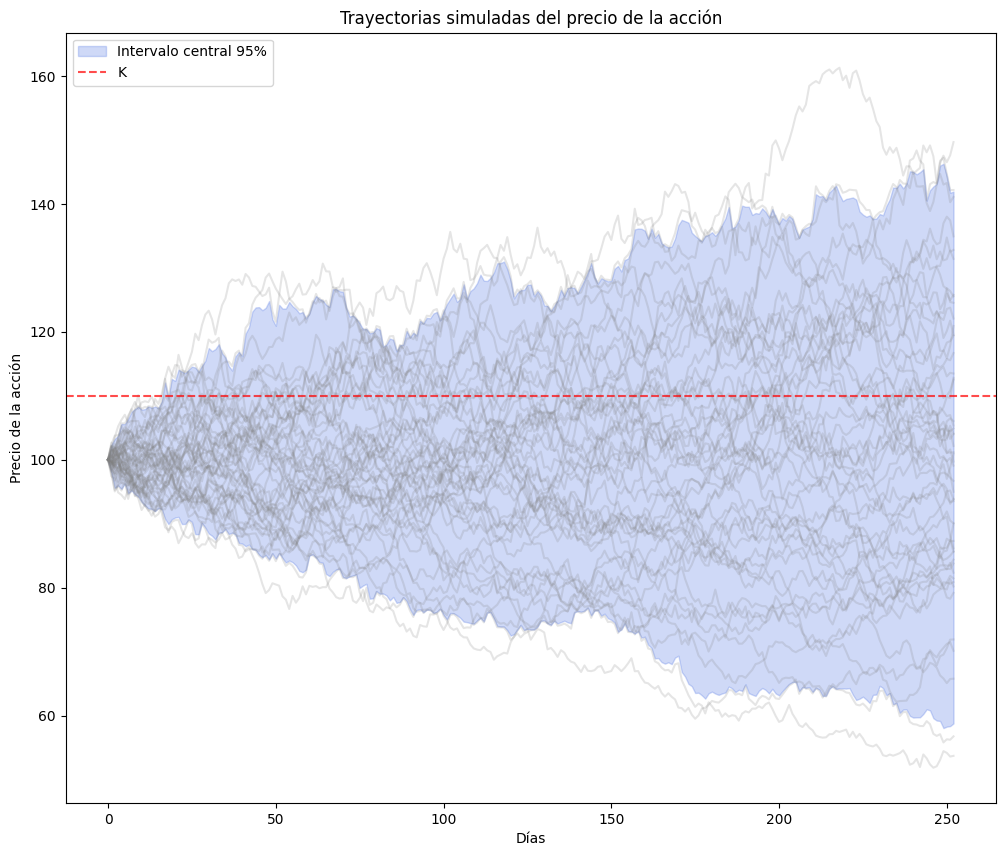

In [53]:
def s(r, sigma, T, S0):
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.normal(0, 1))

trayectorias = []
for i in range(50):
    trayectoria = [100]
    dt = 1/252
    T = 0
    for j in range(252):
        S0 = s(0.05, 0.20, dt, trayectoria[-1])
        trayectoria.append(S0)
    trayectorias.append(trayectoria)

trayectorias = np.array(trayectorias)

limite_inferior, limite_superior = np.percentile(trayectorias, [2.5, 97.5], axis=0)

plt.figure(figsize=(12, 10))
for i in range(trayectorias.shape[0]):
    plt.plot(range(253), trayectorias[i], alpha=0.2, color='grey')
plt.fill_between(range(253), limite_inferior, limite_superior, color='royalblue', alpha=0.25, label='Intervalo central 95%')
plt.title('Trayectorias simuladas del precio de la acción')
plt.axhline(y=110, color='red', linestyle='--', label='K', alpha=0.7)
plt.xlabel('Días')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()

## 2. Simulación de 1000 Trayectorias

Se incrementa el número de simulaciones a 1,000 para las estimaciones Monte Carlo de los promedios y de los payoffs. El precio de ejercicio usado en las opciones es $K=110$.

**Cálculo de promedio de trayectoria para opción asiática**

In [54]:
trayectorias = []
Media = []
Precio_Final = []
for i in range(1000):
    trayectoria = [100]
    dt = 1/252
    T = 0
    for j in range(252):
        S0 = s(0.05, 0.20, dt, trayectoria[-1])
        trayectoria.append(S0)
    trayectorias.append(trayectoria)
    Media.append(np.mean(trayectoria[1:]))
    Precio_Final.append(trayectoria[-1])

Media = np.array(Media)
Precio_Final = np.array(Precio_Final)

Payoff_as_call = np.maximum(Media - 110, 0)
Payoff_as_put = np.maximum(110 - Media, 0)

print(f'Payoff Opcion Asiatica Call: {np.mean(Payoff_as_call):.2f}')
print(f'Payoff Opcion Asiatica Put: {np.mean(Payoff_as_put):.2f}')

Payoff Opcion Asiatica Call: 2.14
Payoff Opcion Asiatica Put: 9.67


**Histograma con payoffs de opción europea y opción asiática**

Una opción europea depende únicamente del precio final $S_T$, mientras que una asiática depende del promedio de la trayectoria. Para una posición larga, los payoffs son $\max(S_T-K,0)$ o $\max(\bar S-K,0)$ para un call, y sus expresiones inversas para un put.

In [55]:
Payoff_eu_call = np.maximum(Precio_Final - 110, 0)
Payoff_eu_put = np.maximum(110 - Precio_Final, 0)

### Posición Long Call

El histograma muestra la frecuencia de los payoffs positivos de los calls simulados.

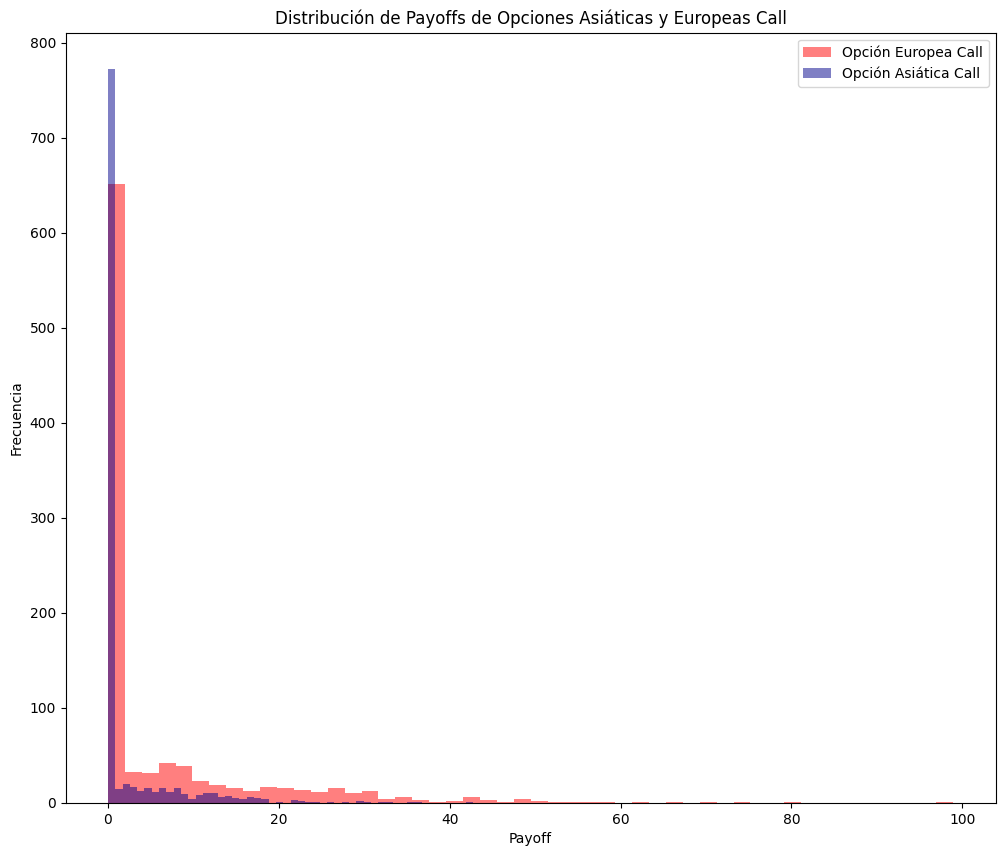

In [56]:

plt.figure(figsize=(12, 10))
plt.hist(Payoff_eu_call, bins=50, alpha=0.5, label='Opción Europea Call', color='red')
plt.hist(Payoff_as_call, bins=50, color='darkblue', alpha=0.5, label='Opción Asiática Call')
plt.xlabel('Payoff')
plt.ylabel('Frecuencia')
plt.title('Distribución de Payoffs de Opciones Asiáticas y Europeas Call')
plt.legend()
plt.show()


### Posición Long Put

Este gráfico presenta los payoffs de una posición larga en put.

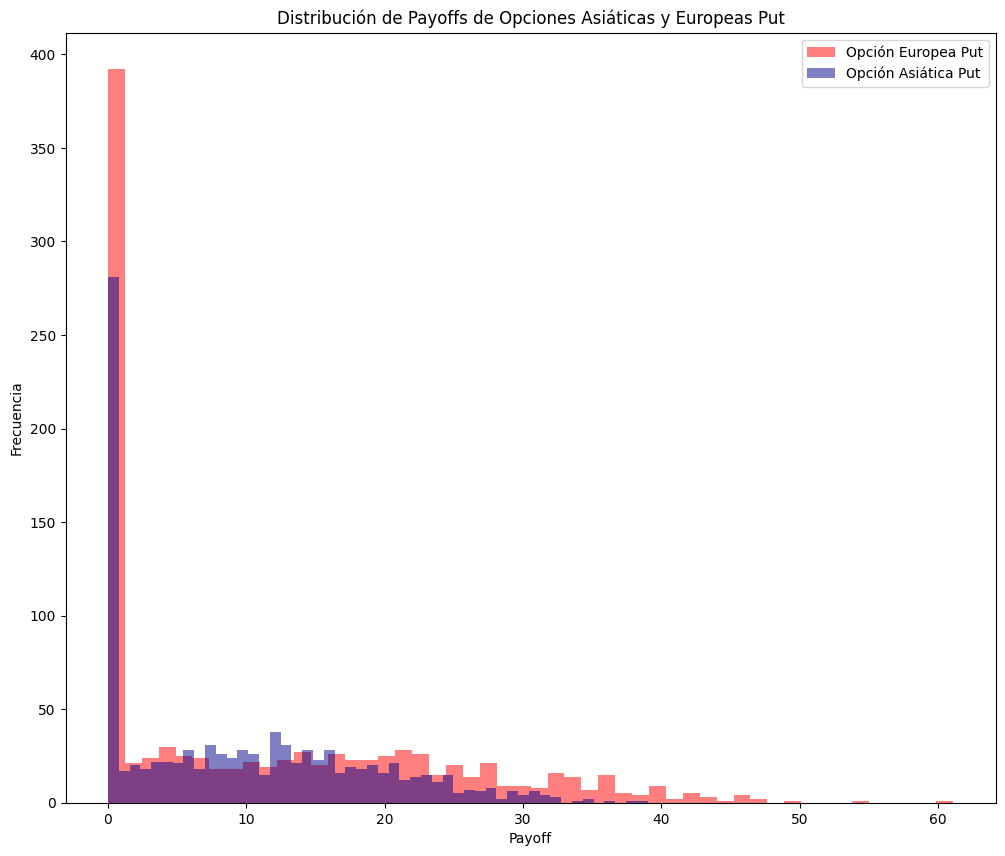

In [57]:
plt.figure(figsize=(12, 10))
plt.hist(Payoff_eu_put, bins=50, alpha=0.5, label='Opción Europea Put', color='red')
plt.hist(Payoff_as_put, bins=50, color='darkblue', alpha=0.5, label='Opción Asiática Put')
plt.xlabel('Payoff')
plt.ylabel('Frecuencia')
plt.title('Distribución de Payoffs de Opciones Asiáticas y Europeas Put')
plt.legend()
plt.show()


**Cálculo de precio de opciones y comparación**

In [58]:
import pandas as pd

df = pd.DataFrame({
    'Asiática': [np.mean(Media), np.mean(Payoff_as_call), np.mean(Payoff_as_put)],
    'Europea': [np.mean(Precio_Final), np.mean(Payoff_eu_call), np.mean(Payoff_eu_put)]
}, index=['Precio', 'Payoff_Call', 'Payoff_Put'])

df

,Asiática,Europea
Precio,102.465992,104.853104
Payoff_Call,2.137534,6.060212
Payoff_Put,9.671542,11.207107


### Conclusión

En estas simulaciones, la opción europea puede exhibir payoffs más dispersos porque depende por completo de $S_T$. La opción asiática usa el promedio $\bar S$ en $t\in[0,T]$, por lo que reduce el efecto de movimientos extremos al final del periodo. Todo esto en base a estos parametros.